# Machine Learning OEL
## CityLearn Building_3 Forecasting using MLP Neural Network

### Muhammad Hanif Khan
### 22JZELE0456

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# Load Dataset


In [21]:

path = r"D:\University\8th Semester\Machine Learning\Labs\OEL\Building_3.csv"

df = pd.read_csv(path)


# Data Collection & Import

In [4]:

print("First Five Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())


First Five Rows
   month  hour  day_type  daylight_savings_status  \
0      6     1         2                        0   
1      6     2         2                        0   
2      6     3         2                        0   
3      6     4         2                        0   
4      6     5         2                        0   

   indoor_dry_bulb_temperature  average_unmet_cooling_setpoint_difference  \
0                    24.140535                                  -0.303909   
1                    23.777792                                  -0.666652   
2                    23.487175                                  -0.957269   
3                    23.285877                                  -1.158567   
4                    22.968086                                  -1.476357   

   indoor_relative_humidity  non_shiftable_load  dhw_demand  cooling_demand  \
0                 73.127610            0.423079         0.0             0.0   
1                 74.936005            0.420

# Data Cleaning

In [23]:


df.drop_duplicates(inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)


# Data Exploration


             month         hour     day_type  daylight_savings_status  \
count  2208.000000  2208.000000  2208.000000                   2208.0   
mean      7.010870    12.500000     3.978261                      0.0   
std       0.814387     6.923755     2.000335                      0.0   
min       6.000000     1.000000     1.000000                      0.0   
25%       6.000000     6.750000     2.000000                      0.0   
50%       7.000000    12.500000     4.000000                      0.0   
75%       8.000000    18.250000     6.000000                      0.0   
max       8.000000    24.000000     7.000000                      0.0   

       indoor_dry_bulb_temperature  average_unmet_cooling_setpoint_difference  \
count                  2208.000000                               2.208000e+03   
mean                     24.231980                              -2.322855e-02   
std                       0.344245                               1.608171e-01   
min               

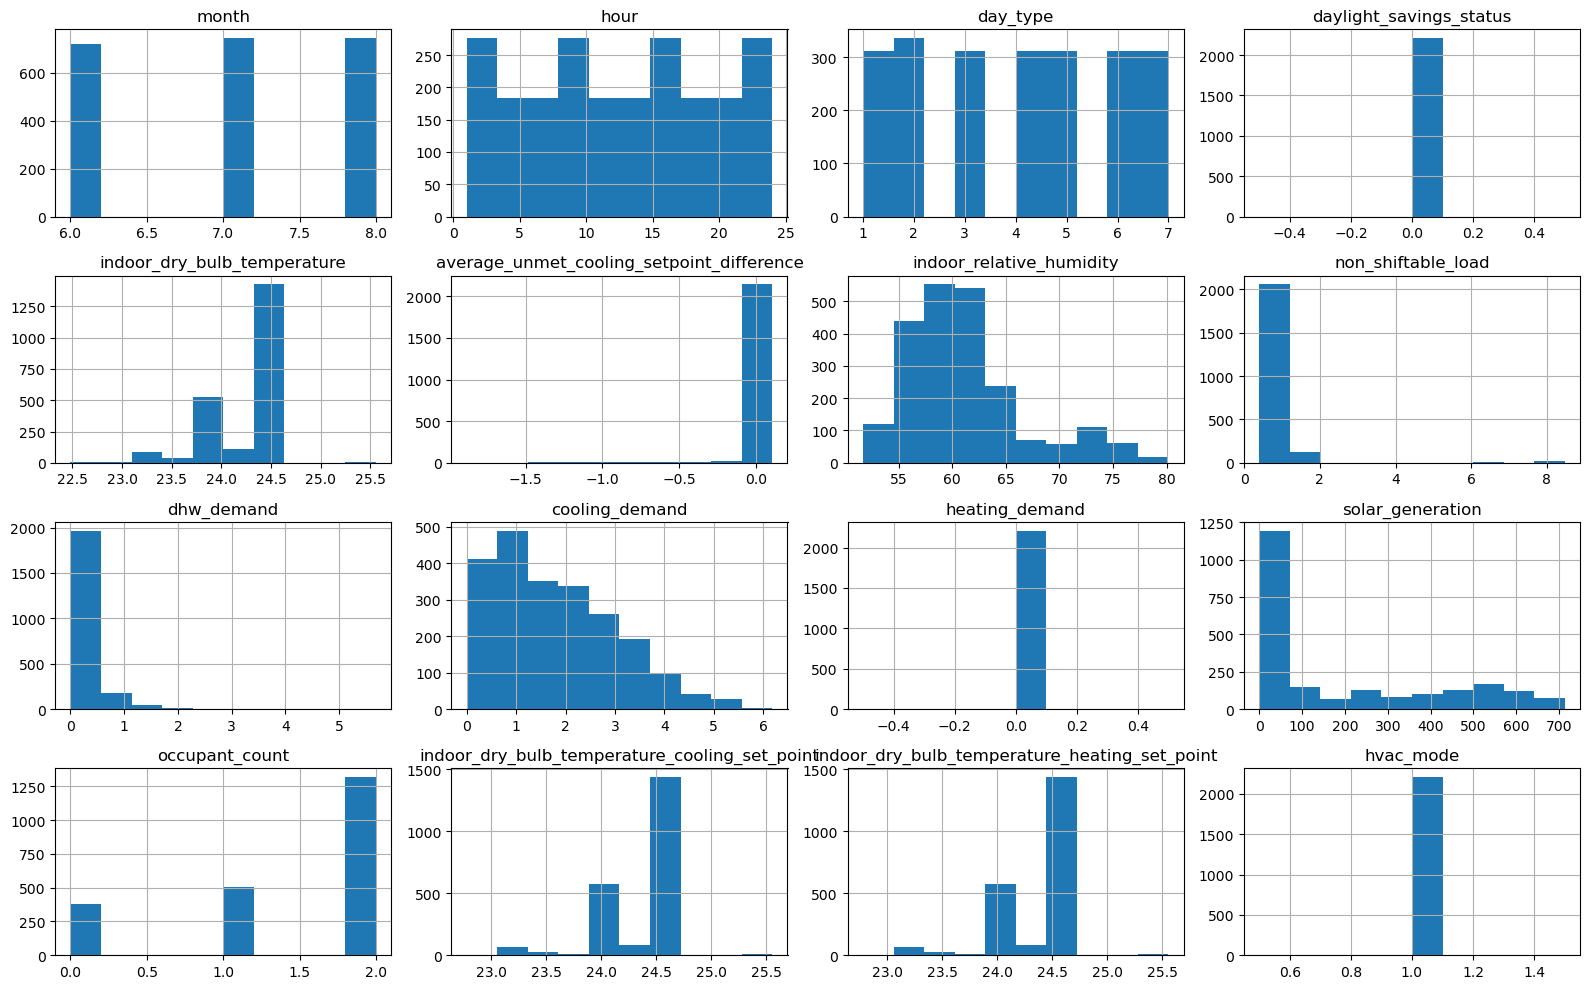

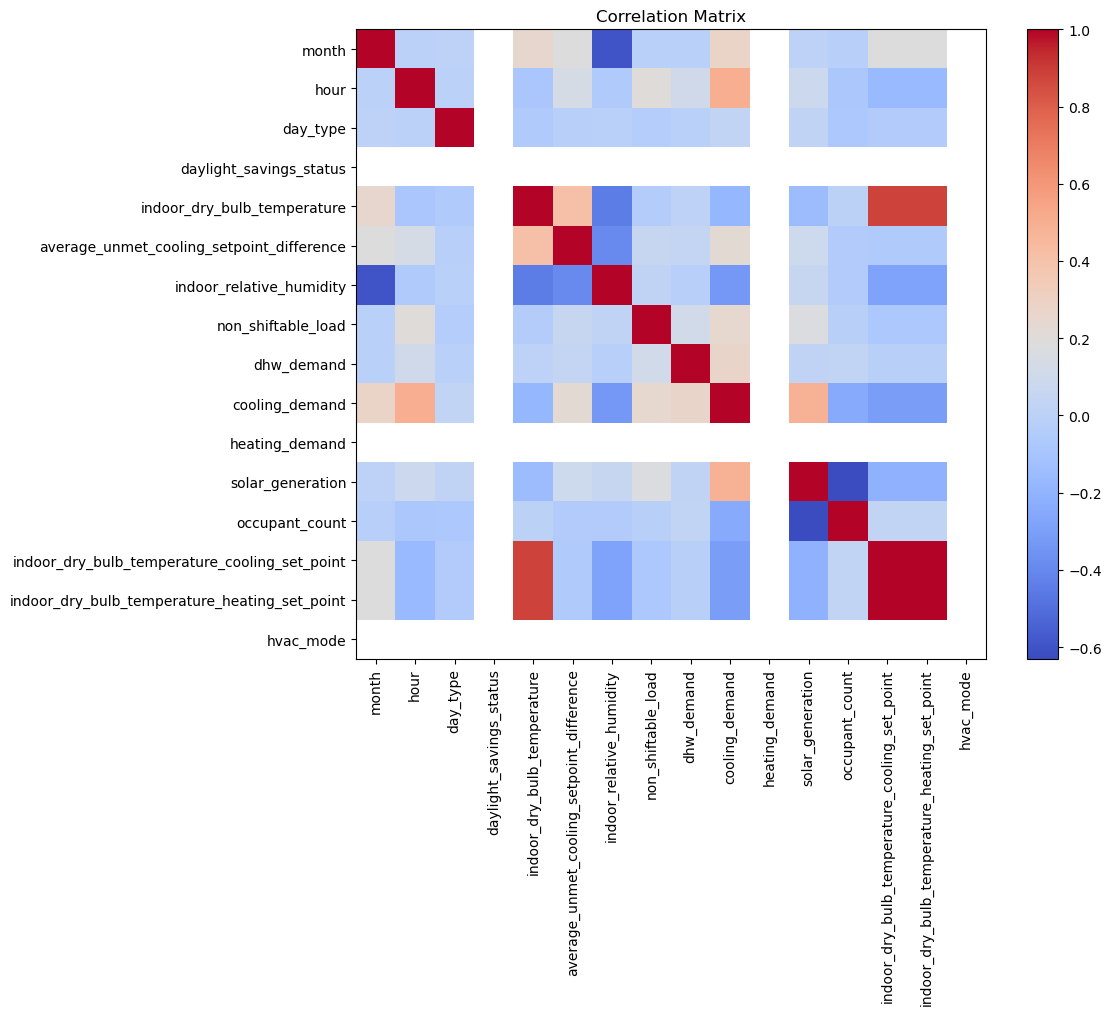

In [7]:


print(df.describe())

# Histograms
df.hist(figsize=(16,10))
plt.tight_layout()
plt.show()

# Correlation Matrix
corr = df.corr()

plt.figure(figsize=(12,10))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


# Feature Engineering & Selection

In [25]:



target = "non_shiftable_load"

X = df.drop(columns=[target])

y = df[target]

# Data Normalization


In [26]:

scaler = StandardScaler()

X = scaler.fit_transform(X)


# Train Test Split

In [27]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Build MLP Model

In [28]:



model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))


C:\Users\Dell\anaconda3\envs\Machine_Learning\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile Model

In [29]:



model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Hyperparameters

In [30]:



early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train Model

In [15]:



history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.9677 - mae: 0.4811 - val_loss: 0.1712 - val_mae: 0.2486
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8135 - mae: 0.3629 - val_loss: 0.1346 - val_mae: 0.2070
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7733 - mae: 0.3538 - val_loss: 0.1268 - val_mae: 0.2002
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7620 - mae: 0.3313 - val_loss: 0.1268 - val_mae: 0.2035
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7551 - mae: 0.3297 - val_loss: 0.1245 - val_mae: 0.2031
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7278 - mae: 0.3278 - val_loss: 0.1310 - val_mae: 0.2132
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7282 - mae: 0.3136 - val_loss: 0.1130 - val_mae: 0.1920
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6972 - mae: 0.3098 - val_loss: 0.1174 - val_mae: 0.1953
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7242 - mae: 

# Prediction

In [31]:



y_pred = model.predict(X_test)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


# Model Evaluation

In [17]:



mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("Model Evaluation")
print("==============================")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score :", r2)



Model Evaluation
MAE : 0.2714829058864048
MSE : 0.7880033704636471
RMSE: 0.8876955392834004
R2 Score : 0.10513029500053483


# Training Loss Graph



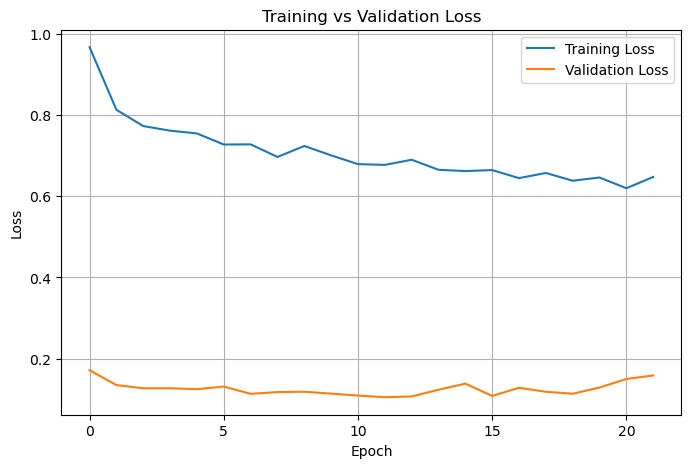

In [24]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# Actual vs Predicted

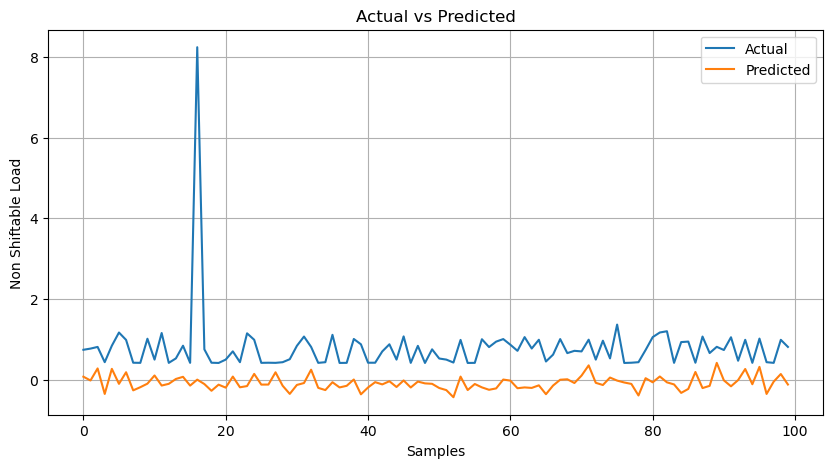

In [32]:

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.xlabel("Samples")
plt.ylabel("Non Shiftable Load")

plt.title("Actual vs Predicted")

plt.legend()

plt.grid(True)

plt.show()

# Finish

In [33]:



print("\nModel Training Completed Successfully.")


Model Training Completed Successfully.
